In [1]:
# BASIC LIBRARIES

!pip install transformers
!pip install opencv-python
!pip install tensorboard
!pip install timm

import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from timm import create_model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm






from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 135.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [2]:
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_GroundTruth.csv"

df = pd.read_csv(METADATA_PATH)

# Assign binary labels: melanoma if MEL==1, else non-melanoma
df['binary_label'] = df['MEL'].apply(lambda x: 1 if x == 1 else 0)

num_melanoma = df[df['binary_label'] == 1].shape[0]
num_non_melanoma = df[df['binary_label'] == 0].shape[0]

print(f"You have {num_melanoma} melanoma images in your ISIC 2019 training dataset.")
print(f"You have {num_non_melanoma} non-melanoma images in your ISIC 2019 training dataset.")



You have 20809 melanoma images in your ISIC 2019 training dataset.
You have 20809 non-melanoma images in your ISIC 2019 training dataset.


Class-to-Index Mapping: {'Benign': 0, 'Melanoma': 1}
Total images in dataset: 41618


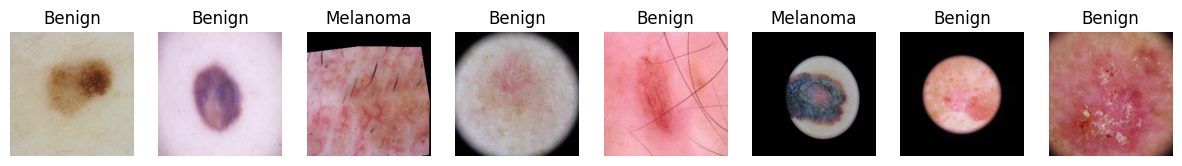

Training set size: 35375
 - Melanoma images in training: 17676
 - Benign images in training: 17699
Validation set size: 6243
 - Melanoma images in validation: 3133
 - Benign images in validation: 3110


In [3]:
# Dataloader
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from collections import Counter

# Dataset directory containing 'Benign/' and 'Melanoma/' subfolders
DATA_DIR = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized"

# Confirm required class folders exist
assert os.path.isdir(os.path.join(DATA_DIR, "Benign")), "'Benign' folder is missing"
assert os.path.isdir(os.path.join(DATA_DIR, "Melanoma")), "'Melanoma' folder is missing"

# Image preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load full dataset (all images)
dataset = ImageFolder(root=DATA_DIR, transform=transform)
print("Class-to-Index Mapping:", dataset.class_to_idx)
print(f"Total images in dataset: {len(dataset)}")  # Expect ~41,618

# Split dataset: 85% train, 15% val
train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

# Function to visualize images with labels
def show_images(images, labels, class_names, n=8):
    images = images[:n]
    labels = labels[:n]
    images = images.numpy().transpose((0, 2, 3, 1))  # [B,C,H,W] -> [B,H,W,C]

    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        axes[i].imshow(images[i])
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis('off')
    plt.show()

# Visualize some random samples from training set
images, labels = next(iter(train_loader))
show_images(images, labels, dataset.classes, n=8)

# Count melanoma and benign in train and val splits
train_labels = [dataset[idx][1] for idx in train_dataset.indices]
val_labels = [dataset[idx][1] for idx in val_dataset.indices]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print(f"Training set size: {len(train_dataset)}")
print(f" - Melanoma images in training: {train_counts[dataset.class_to_idx['Melanoma']]}")
print(f" - Benign images in training: {train_counts[dataset.class_to_idx['Benign']]}")

print(f"Validation set size: {len(val_dataset)}")
print(f" - Melanoma images in validation: {val_counts[dataset.class_to_idx['Melanoma']]}")
print(f" - Benign images in validation: {val_counts[dataset.class_to_idx['Benign']]}")


In [13]:
# LETS GO BERSERK!

import torch.nn as nn
import torch.optim as optim
from torchvision import models
from timm import create_model

# with Ballanced Dataset ISIC 2019
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone va Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # It removes classifier (keeps features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from ResNet
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        # Extract features from EfficientNet
        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        # Extract features from DenseNet
        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]        # Get last feature map
        swin_out = self.global_pool(swin_feats)   # (B, C, 1, 1)
        swin_out = torch.flatten(swin_out, 1)     # Now (B, C)

        # Concatenate all features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Classification head
        out = self.fc(combined_features)
        return out


# Config
NUM_CLASSES = 2  # Only Benign and Melanoma
checkpoint_path = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth"

# Initialize model and optimizer
model = Berserker(num_classes=NUM_CLASSES)
optimizer = optim.AdamW(
    params=[p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

# Load checkpoint if exists
start_epoch = 0
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Resumed from epoch {start_epoch}")

# Training loop
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path=None, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for inputs, targets in tqdm(train_loader, desc="Training"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc="Validation"):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        # Checkpoint logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            if checkpoint_path:
                print(f"Validation loss improved to {val_loss:.4f}, saving checkpoint...")
                torch.save({
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                }, checkpoint_path)
                print(f"Checkpoint saved at {checkpoint_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                break

# Start training
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path=checkpoint_path)



Epoch 1/10


Validation: 100%|██████████| 49/49 [02:21<00:00,  2.89s/it]


Train Loss: 0.3722 | Train Acc: 82.8184
Val Loss:   0.3101 | Val Acc:   86.1124
Validation loss improved to 0.3101, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth

Epoch 2/10


Validation: 100%|██████████| 49/49 [02:21<00:00,  2.90s/it]


Train Loss: 0.3163 | Train Acc: 85.5322
Val Loss:   0.2978 | Val Acc:   86.8813
Validation loss improved to 0.2978, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth

Epoch 3/10


...

Train Loss: 0.2261 | Train Acc: 90.2530
Val Loss:   0.2471 | Val Acc:   89.2680
Validation loss improved to 0.2471, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth

Epoch 9/10


Validation: 100%|██████████| 49/49 [02:21<00:00,  2.89s/it]


Train Loss: 0.2127 | Train Acc: 90.9230
Val Loss:   0.2448 | Val Acc:   89.2520
Validation loss improved to 0.2448, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth

Epoch 10/10


Validation: 100%|██████████| 49/49 [02:21<00:00,  2.90s/it]


Train Loss: 0.2019 | Train Acc: 91.4883
Val Loss:   0.2391 | Val Acc:   89.4282
Validation loss improved to 0.2391, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth


Test set size: 6580


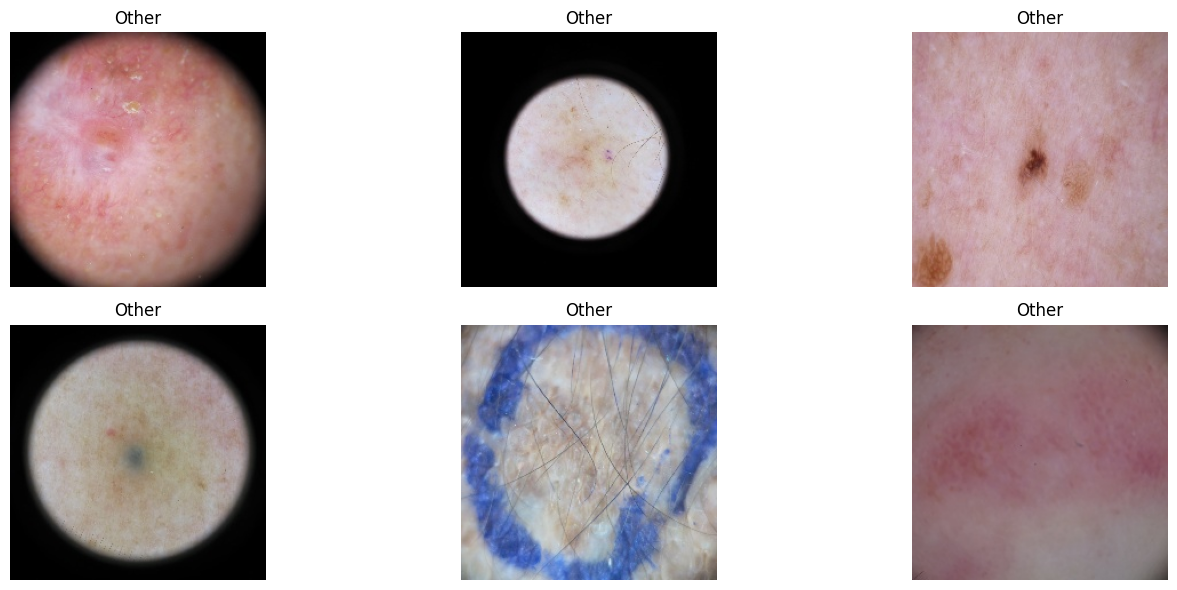

In [20]:
# Test Dataset Loader

# Required Imports
import random
from glob import glob
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
ISIC_2019_TEST_PATH = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Normalized'
BATCH_SIZE = 128
IMG_SIZE = 224
NUM_WORKERS = 8
TEST_CLASS_NAMES = ['Other', 'Melanoma']  # label 0 = Other, 1 = Melanoma

# Transform (Matches training setup: [0,255] → [0,1] → [-1,1])
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Dataset Class
class ISIC2019TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for label, cls in enumerate(TEST_CLASS_NAMES):
            cls_dir = os.path.join(root_dir, cls)
            image_paths = glob(os.path.join(cls_dir, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = cv2.imread(path)
        if image is None:
            raise RuntimeError(f"Could not read image at {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

# DataLoader
test_dataset = ISIC2019TestDataset(root_dir=ISIC_2019_TEST_PATH, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Test set size: {len(test_dataset)}")

# Denormalization (for visualization only)
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5
    return tensor.clamp(0, 1)

# Visualize Random Samples
def visualize_test_samples(dataset, num_images=6):
    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(TEST_CLASS_NAMES[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# View Some Samples
visualize_test_samples(test_dataset)



Testing: 100%|██████████| 52/52 [07:32<00:00,  8.70s/it]



Test Accuracy: 0.6684
Precision: 0.2793
Recall (Sensitivity): 0.6797
F1 Score: 0.3959

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.67      0.77      5528
    Melanoma       0.28      0.68      0.40      1052

    accuracy                           0.67      6580
   macro avg       0.60      0.67      0.58      6580
weighted avg       0.81      0.67      0.71      6580


Confusion Matrix:
[[3683 1845]
 [ 337  715]]


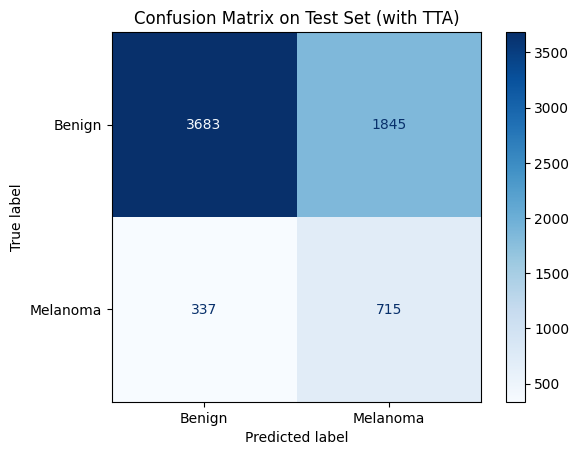

AUC: 0.7420


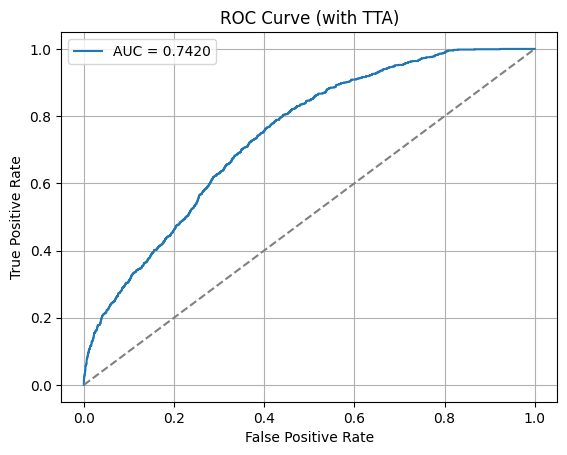

In [27]:

best_checkpoint_path =  "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth"
# Testing with TTA on ISIS 2019 Test Dataset

import torchvision.transforms as T
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Berserker(num_classes=2)
model.to(device)

checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# transforms
tta_transforms = [
    T.Compose([]),  # original
    T.Compose([T.RandomHorizontalFlip(p=1.0)]),
    T.Compose([T.RandomVerticalFlip(p=1.0)]),
]

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)

        batch_size = images.size(0)
        probs_tta = torch.zeros(batch_size, 2).to(device)  # for accumulating TTA probs

        # Apply each TTA transform on the batch
        for transform in tta_transforms:
            # Transform expects PIL Image or Tensor in [C,H,W], here images are tensors.
            # Since images come as batches, apply transform per image
            augmented_images = torch.stack([transform(img.cpu()) for img in images]).to(device)

            outputs = model(augmented_images)
            probs = torch.softmax(outputs, dim=1)
            probs_tta += probs

        probs_tta /= len(tta_transforms)  # average probs over all TTA versions

        threshold = 0.94  # threshold for melanoma prob
        preds = (probs_tta[:, 1] > threshold).long()

        all_probs.extend(probs_tta[:, 1].cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Set averaging method based on output shape
average_type = 'binary' if model.fc[-1].out_features == 2 else 'weighted'

# Metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=average_type, zero_division=0)
recall = recall_score(all_labels, all_preds, average=average_type, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=average_type, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Melanoma"]))
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Melanoma"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set (with TTA)")
plt.savefig("confusion_matrix_test_tta.png")
plt.show()

if model.fc[-1].out_features == 2:
    auc = roc_auc_score(all_labels, all_probs)
    print(f"AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (with TTA)")
    plt.legend()
    plt.grid(True)
    plt.savefig("roc_curve_test_tta.png")
    plt.show()


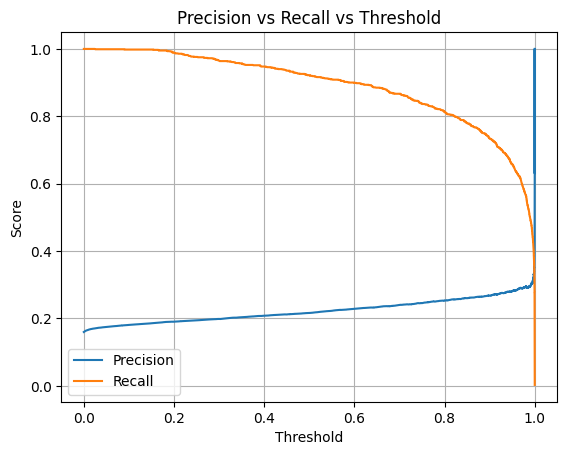

Best F1 score: 0.3967 at threshold 0.94


In [28]:
from sklearn.metrics import precision_recall_curve
from numpy import argmax


precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()



f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = argmax(f1_scores)
print(f"Best F1 score: {f1_scores[best_idx]:.4f} at threshold {thresholds[best_idx]:.2f}")


In [7]:
# LETS GO BERSERK!

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from timm import create_model
from tqdm import tqdm

# Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Berserker Model
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()
        self.num_classes = num_classes

        # Backbones
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])

        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze then partially unfreeze
        for param in self.resnet_feat.parameters():
            param.requires_grad = False
        for name, child in resnet.named_children():
            if name == 'layer4':
                for param in child.parameters():
                    param.requires_grad = True

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False
        for layer in list(efficientnet.children())[-3:]:
            for param in layer.parameters():
                param.requires_grad = True

        for param in self.densenet_feat.parameters():
            param.requires_grad = False
        for param in self.densenet_feat.denseblock4.parameters():
            param.requires_grad = True

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Unfreeze last stage of Swin (usually index -1)
        if hasattr(self.swin_feat, 'blocks'):
            for param in self.swin_feat.blocks[-1].parameters():
                param.requires_grad = True
        elif hasattr(self.swin_feat, 'body'):
            for param in self.swin_feat.body[-1].parameters():
                param.requires_grad = True
        else:
            # For generic feature extractor fallback (e.g., features_only=True returns list)
            for param in self.swin_feat[-1].parameters():
                param.requires_grad = True


        # Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Feature size manually defined
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_out = self.global_pool(self.resnet_feat(x))
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.global_pool(self.efficientnet_feat(x))
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.global_pool(self.densenet_feat(x))
        densenet_out = torch.flatten(densenet_out, 1)

        swin_feats = self.swin_feat(x)[-1]
        swin_out = self.global_pool(swin_feats)
        swin_out = torch.flatten(swin_out, 1)

        combined_features = torch.cat((resnet_out, efficientnet_out, densenet_out, swin_out), dim=1)
        return self.fc(combined_features)

# Config
NUM_CLASSES = 2
checkpoint_path = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/only_2019.pth"

model = Berserker(num_classes=NUM_CLASSES)
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)
criterion = FocalLoss(alpha=0.25, gamma=2.0)

start_epoch = 0
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Resumed from epoch {start_epoch}")

def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path=None, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for inputs, targets in tqdm(train_loader, desc="Training"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc="Validation"):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            if checkpoint_path:
                print(f"Validation loss improved to {val_loss:.4f}, saving checkpoint...")
                torch.save({
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                }, checkpoint_path)
                print(f"Checkpoint saved at {checkpoint_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                break


KeyError: -1